In [5]:
import pandas as pd

prop = pd.read_csv("~/Downloads/propiedades.csv")
precios = pd.read_csv("~/Downloads/precioscasas.csv")

In [16]:
print(prop.head())
print(precios.head())

   Price_CLP  Price_UF  Price_USD        Comuna  \
0  129884400    3600.0   158396.0         Lampa   
1  130000000    3603.0   158537.0          Buin   
2  172998805    4795.0   210974.0    PuenteAlto   
3  135296250    3750.0   164995.0          Buin   
4  195000000    5405.0   237805.0  QuintaNormal   

                         Ubicacion  Dorms  Baths  Built Area  Total Area  \
0                AvenidaLaHacienda    3.0    2.0        68.0       221.0   
1                        Villaseca    5.0    3.0       150.0       190.0   
2                    BarrioAustria    4.0    3.0        90.0       182.0   
3  ComercianteArmandoPérezCarrasco    3.0    2.0        85.0       175.0   
4                           Hostos    3.0    3.0       130.0       402.0   

   Parking        id               Realtor  
0      1.0   7850612               Behouse  
1      2.0  10081485                   NaN  
2      3.0  10257247                Bissac  
3      1.0  20153043  Ambiento Propiedades  
4      1.0 

In [40]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline




In [44]:
df = precios.dropna()

df = df[df["Price_CLP"] < df["Price_CLP"].quantile(0.99)]
df = df[df["Total Area"] > 20]
df = df[df["Dorms"] > 0]
df = df[df["Price_UF"] > 0]
df["log_price"] = np.log(df["Price_UF"])

df["built_ratio"] = df["Built Area"] / df["Total Area"]
df["density_rooms"] = df["Dorms"] / df["Total Area"]
df["area_per_room"] = df["Total Area"] / df["Dorms"]
df["bath_per_room"] = df["Baths"] / df["Dorms"]
df["area_interaction"] = df["Built Area"] * df["Total Area"]
df["TotalArea2"] = df["Total Area"] ** 2
df["BuiltArea2"] = df["Built Area"] ** 2

df = df.replace([np.inf, -np.inf], np.nan).dropna()

df = df[(df["Total Area"] < 400) & (df["Built Area"] < 300)]

df["Comuna"] = df["Comuna"].astype(str)
df = pd.get_dummies(df, columns=["Comuna"], drop_first=True)

df = df.drop(columns=["Price_CLP", "Price_USD", "Price_UF", "Ubicacion"], errors="ignore")

X = df.drop(columns=["log_price"])
y = df["log_price"]

X = X.drop(columns=["id", "Parking"], errors="ignore")
X = X.apply(pd.to_numeric, errors="coerce").dropna(axis=1)

from sklearn.preprocessing import PolynomialFeatures

pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
print("R2 CV base:", scores.mean())

param_grid = {
    "model__alpha": [1, 10, 50, 100, 200]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="r2")
grid.fit(X, y)

print("Mejor R2:", grid.best_score_)
print("Mejor alpha:", grid.best_params_)

best_model = grid.best_estimator_

feature_names = best_model.named_steps["poly"].get_feature_names_out(X.columns)

coefs = pd.Series(best_model.named_steps["model"].coef_, index=feature_names)
coefs = coefs.sort_values(key=abs, ascending=False)

print("\nTop 10 variables:")
print(coefs.head(10))

R2 CV base: 0.7521157600130893
Mejor R2: 0.8245341605330303
Mejor alpha: {'model__alpha': 200}

Top 10 variables:
Dorms area_per_room             0.061091
Total Area                      0.061091
Baths                           0.058187
Dorms bath_per_room             0.058187
Built Area                      0.046933
Total Area built_ratio          0.046933
built_ratio Comuna_LasCondes    0.044936
density_rooms                  -0.044103
Comuna_LasCondes^2              0.039738
Comuna_LasCondes                0.039738
dtype: float64


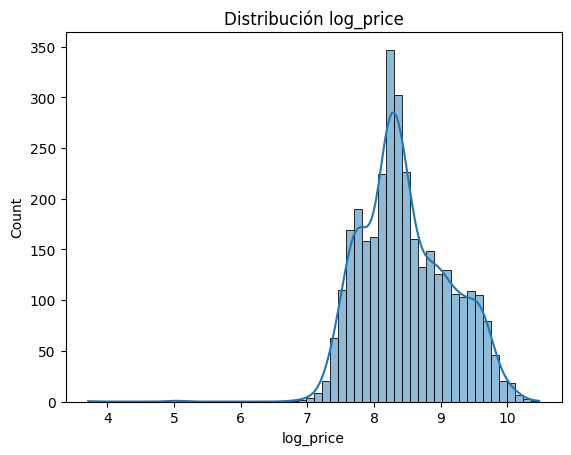

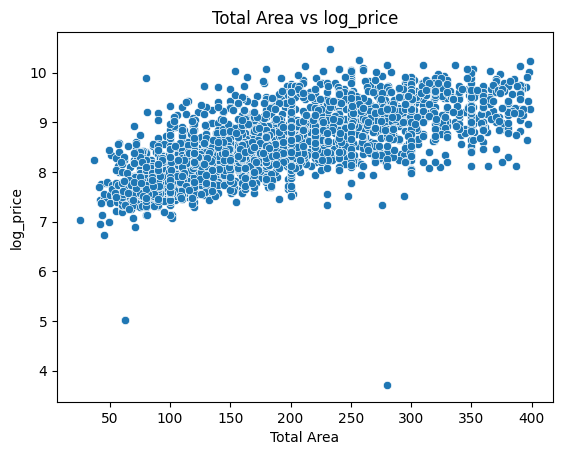

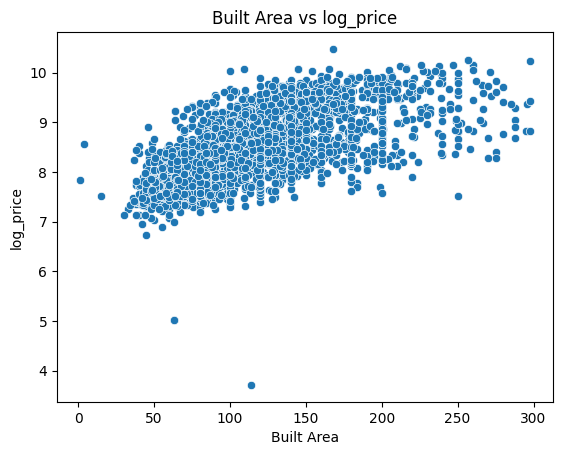

<Figure size 1000x800 with 0 Axes>

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.histplot(df["log_price"], kde=True)
plt.title("Distribución log_price")
plt.show()

plt.figure()
sns.scatterplot(x=df["Total Area"], y=df["log_price"])
plt.title("Total Area vs log_price")
plt.show()

plt.figure()
sns.scatterplot(x=df["Built Area"], y=df["log_price"])
plt.title("Built Area vs log_price")
plt.show()


plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
